# 1. Imports

In [1]:
import pandas as pd
import numpy as np
import polars as pl
import pyarrow as pa
import altair as alt

import re
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction import text as sk_text
from wordcloud import WordCloud
import matplotlib.pyplot as plt

import glob
import json
from pathlib import Path

import calendar
import geopandas as gpd
from geodatasets import get_path
from shapely.geometry import Point
import branca.colormap as cm

import folium
from folium.plugins import MarkerCluster
import folium
from folium.plugins import MarkerCluster
from folium.elements import MacroElement
from jinja2 import Template

DATA_PATH = Path("../data/UpdatedData/citibike_2023_combined.parquet/")
OUTPUT_PATH = Path("../output/")

# 2. Data Load & Process

Processing script should be in `preprocessing.ipynb`.

In [2]:
df = (
    pl.read_parquet(f"{DATA_PATH}/*.parquet")
    # 1) Parse to datetime and rename in one go
    .with_columns(
        pl.col("started_at").str.to_datetime().alias("start_time"),
        pl.col("ended_at").str.to_datetime().alias("end_time"),
    )
    # 2) Compute ride_time_seconds = end_time - start_time (in seconds)
    .with_columns(
        (pl.col("end_time") - pl.col("start_time"))
        .dt.total_seconds()
        .alias("ride_time_seconds")
    )
    # 3) Order by start_time
    .sort("start_time")
    # 4) Select columns in the exact order you want
    .select(
        "ride_id",
        "rideable_type",
        "start_time",
        "end_time",
        "ride_time_seconds",   # ← right after end_time
        "start_station_name",
        "start_station_id",
        "end_station_name",
        "end_station_id",
        "start_lat",
        "start_lng",
        "end_lat",
        "end_lng",
        "member_casual",
    )
)

# remove any start or end_station_name = null
df = df.filter(pl.col("end_station_name").is_not_null())
df= df.filter(pl.col("end_station_id").is_not_null())
df = df.filter(pl.col("start_station_name").is_not_null())
df= df.filter(pl.col("start_station_id").is_not_null())

# filter data out for ride_time < 2 hours or way too short ones like 1 minute
df = df.filter(pl.col("ride_time_seconds") < 2 * 3600)   
df = df.filter(pl.col("ride_time_seconds") >= 60)

df = df.filter(pl.col("start_time").dt.year() == 2023)
df = df.with_columns([
    pl.col("start_time").dt.month().alias("month"),
])

In [3]:
# filter data out for ride time that is negative or zero (not possible)
df = df.filter(pl.col("ride_time_seconds") > 0)

# Remove rides with identical start/end stations (probably some error)
df = df.filter(
    ~(
        (pl.col("start_station_id") == pl.col("end_station_id"))
    )
)

df = df.filter(
    ~(
        (pl.col("start_lat") == pl.col("end_lat"))
        & (pl.col("start_lng") == pl.col("end_lng"))
    )
)

# 3. Visualization

### 3.3 NYC Interactive Bike Line Charts

### 3.3.1. Daily Ride Patterns: What Does Day-to-Day Activity Look Like?

QUESTION: What day to day patterns show we explore ride activity through time.

The daily chart gives a much closer look at how rides change from one day to the next. Instead of smoothing the data across longer periods, this view highlights smaller movements that happen throughout the week. You can immediately see the rises and drops in activity as you move through the timeline.

When you interact with the plot, it becomes clear that certain days draw more rides than others. Patterns like weekday peaks, weekend slowdowns, or unexpected spikes show up quickly. This makes it easy to see how people use bikes in their everyday routines and how those patterns shift throughout different months.

The filters help break things down even further. You can compare classic and electric bikes or look at differences between member and non-member riders. This adds more detail to the overall pattern and helps explain why some days look busier than others.

Putting it all together, the daily plot connects the broader seasonal trends to the smaller patterns happening at the day-to-day level. It gives a clearer picture of how the bike system is used in real time and how rider behavior changes across the year.

### 3.3.1.1 Data Preparation

In [4]:
# pull out date, bike type, rider type, and daily ride counts
daily_grouped = (
    df.with_columns(pl.col("start_time").dt.date().alias("date"))
      .group_by(["date", "rideable_type", "member_casual"])
      .agg(pl.len().alias("ride_count"))
      .sort("date")
      .to_pandas()
)

# make sure date column is in proper datetime format
daily_data = daily_grouped.copy()
daily_data["date"] = pd.to_datetime(daily_data["date"])
daily_data = daily_data.sort_values("date")
daily_data.head()

,date,rideable_type,member_casual,ride_count
0,2023-01-01,electric_bike,member,18545
1,2023-01-01,classic_bike,member,14843
2,2023-01-01,classic_bike,casual,6288
3,2023-01-01,electric_bike,casual,7728
4,2023-01-02,electric_bike,member,22730


I used Polars to do the heavy processing since it's faster, and then switched the small grouped result to Pandas with .to_pandas() so I could use the plotting libraries without crashing the kernel.

### 3.3.1.2 NYC Daily Ride Patterns Interactive Line Chart

In [17]:
# dropdown options for bike type filter
bike_types = sorted(daily_data["rideable_type"].unique().tolist())

bike_dropdown = alt.binding_select(
    options=bike_types,
    name="Bike type: "
)

# selection for bike type
bike_select = alt.selection_point(
    fields=["rideable_type"],
    bind=bike_dropdown,
    value=bike_types[0]     
)

# selection for rider type (member / casual)
rider_select = alt.selection_point(
    fields=["member_casual"],
    bind="legend"
)

# daily interactive plot
daily_chart = (
    alt.Chart(daily_data)
        .mark_line()
        .encode(
            x=alt.X("date:T", title="Day-by-Day in 2023", 
                    axis=alt.Axis(format="%b", labelAngle=0)), # Format the x-axis with month abbreviations to avoid overlapping 
            y=alt.Y("ride_count:Q", title="Number of Rides(in thousands)", axis=alt.Axis(format="~s")),
            color=alt.Color("member_casual:N", title="Rider type"),
            tooltip=[
                alt.Tooltip("date:T", title="Day-by-Day in 2023"),
                alt.Tooltip("rideable_type:N", title="Bike type"),
                alt.Tooltip("member_casual:N", title="Rider type"),
                alt.Tooltip("ride_count:Q", title="Number of rides"),
            ],
        )
        .add_params(bike_select, rider_select)
        .transform_filter(bike_select)
        .transform_filter(rider_select)
        .properties(
            width=700,
            height=400,
            title="Daily City Bike Trips in 2023 (Interactive)",
        )
        .interactive()     
)
daily_chart

alt.Chart(...)

From the above plot, it is clear that NYC Bike usage rises as the weather warms, peaks in late summer, and drops in the colder months. Casual riders increase sharply on warm days and weekends, while members ride more steadily year-round. Classic bikes remain the most used, but e-bike trips grow noticeably over time. Overall, the chart highlights how season, weather, and rider type shape daily ridership.

### 3.3.2. Weekly Ride Patterns

Question: What Weekly Patterns Can We See in City Bike Usage?

The weekly view gives a clean, zoomed-out look at how bike usage changes across the year. Instead of focusing on day-to-day ups and downs, this chart smooths things out, making it easier to spot bigger trends. It can be observed that the ridership climbs during warmer months or dips during quieter times of the year.

This weekly view also helps highlight how different bike types and rider groups vary throughout the year. By smoothing out the daily fluctuations and letting you filter by category, the chart provides a clear comparison of usage patterns week by week. It offers a straightforward way to see how ridership shifts across seasons and between user groups.

### 3.3.2.1 Data Preparation for the weekly ride patterns

In [6]:
# create week number and count rides by week
weekly_grouped = (
    df.with_columns(pl.col("start_time").dt.week().alias("week"))
      .group_by(["week", "rideable_type", "member_casual"])
      .agg(pl.len().alias("ride_count"))
      .sort("week")
      .to_pandas()
)
weekly_grouped.head()

,week,rideable_type,member_casual,ride_count
0,1,electric_bike,member,184039
1,1,electric_bike,casual,35675
2,1,classic_bike,casual,26026
3,1,classic_bike,member,169405
4,2,classic_bike,casual,18175


### 3.3.2.2 NYC Weekly Ride Patterns Interactive Line Chart

In [19]:
# dropdown options for bike type filter
bike_types_weekly = sorted(weekly_grouped["rideable_type"].unique().tolist())

bike_dropdown_weekly = alt.binding_select(
    options=bike_types_weekly,
    name="Bike type: "
)

# selection for bike type
bike_select_weekly = alt.selection_point(
    fields=["rideable_type"],
    bind=bike_dropdown_weekly,
    value=bike_types_weekly[0]     
)

# selection for rider type (member / casual) via legend
rider_select_weekly = alt.selection_point(
    fields=["member_casual"],
    bind="legend"
)

# weekly interactive line chart
weekly_chart = (
    alt.Chart(weekly_grouped)
        .mark_line()
        .encode(
            x=alt.X("week:O", title="Week of Year 2023", axis=alt.Axis(labelAngle=0, values=list(range(1, 53, 5)))),
            y=alt.Y("ride_count:Q", title="Number of Rides(in thousands)", axis=alt.Axis(format="~s")),
            color=alt.Color("member_casual:N", title="Rider type"),  # legend for selecting rider type
            tooltip=[
                alt.Tooltip("week:O", title="Week"),
                alt.Tooltip("rideable_type:N", title="Bike type"),
                alt.Tooltip("member_casual:N", title="Rider type"),
                alt.Tooltip("ride_count:Q", title="Number of Rides", format="~s"),
            ],
        )
        .add_params(bike_select_weekly, rider_select_weekly)
        .transform_filter(bike_select_weekly)
        .transform_filter(rider_select_weekly)
        .properties(
            width=700,
            height=400,
            title="Weekly City Bike Trips in 2023 (Interactive)",
        )
        .interactive()
)
weekly_chart

alt.Chart(...)

The weekly trends show that members ride more consistently throughout the year, while casual riders have bigger ups and downs. Both groups peak in the warmer months and drop off during colder weeks. Overall, the chart gives a straightforward look at how different riders and bike types contribute to changes in usage week by week.

### 3.4. NYC Bike Share Text Analysis: What Words Are Most Associated With City Bike Usage?

The station names actually tell us a lot about how the city’s bike system fits into the places people move through every day. Many of these names come straight from recognizable neighborhoods, parks, major avenues, and busy intersections. When we look at the text more closely, it becomes clear that the system naturally overlaps with the kinds of places people already talk about in everyday life. That makes station names a helpful way to see how biking connects to the city’s familiar landscape.

Once the station names are broken into individual words and short phrases, the most prominent locations in the network become easy to spot. Words like broadway, park, washington, grand, and bedford appear much larger in the word cloud because they show up across many different station names throughout the city. These bigger, bolder terms give a quick sense of the areas that have a strong presence in the bike system, highlighting the neighborhoods, avenues, and landmarks that riders regularly encounter.

To make the patterns easier to interpret, common filler words are removed so the focus stays on the parts of the station names that actually describe real places. The remaining words are a collection of meaningful location references that reflect the character of the city’s streets and neighborhoods. Seeing these terms grouped together makes it easier to notice the locations that come up again and again in station names.

This gives a quick, easy look at the spots that really show up in day-to-day riding. It also makes it clear how naturally the bike system lines up with the places people already move through and talk about in the city.

### 3.4.1  Data Preparation for Text Analysis

In [20]:
# pull all station names from both start and end columns
all_names_raw = (
    pl.concat([
        df.select(pl.col("start_station_name").alias("name")),
        df.select(pl.col("end_station_name").alias("name")),
    ])
    .drop_nulls("name")
    .unique()
)
station_list = all_names_raw["name"].to_list()

def clean_name(text: str) -> str:    # quick cleaner for station names
    text = text.lower()
    # remove punctuation and tidy spaces
    text = re.sub(r"[^a-z0-9\s]", " ", text)    
    text = re.sub(r"\s+", " ", text).strip()     
    return text  

cleaned_names = [clean_name(n) for n in station_list]

# words we want to remove so results stay meaningful
extra_stops = {
    "station", "street", "st", "st.", "ave", "avenue",
    "blvd", "road", "rd", "plaza", "pl", "sq",
    "north", "south", "east", "west", "n", "s", "e", "w",
    "citi", "bike", "bikes", "citibike", "citibikenyc",
    "new", "york", "nyc",
}

# merge default english stopwords with our custom list
all_stops = list(sk_text.ENGLISH_STOP_WORDS.union(extra_stops))

# turn station names into single words + two-word phrases
vec = CountVectorizer(
    stop_words=all_stops,
    ngram_range=(1, 2),      
    min_df=2                 
)

matrix = vec.fit_transform(cleaned_names)
ngram_terms = vec.get_feature_names_out()
ngram_counts = matrix.sum(axis=0).A1

# the terms sorted by how often they appear
ngram_table = (
    pd.DataFrame({"term": ngram_terms, "count": ngram_counts})
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)
print("Top 10 location words:")
print(ngram_table.head(10))

Top 10 location words:
         term  count
0        park    101
1    broadway     96
2       grand     45
3          10     40
4          31     38
5          dr     38
6  washington     37
7     madison     36
8        pkwy     32
9          34     30


### 3.4.2 Word Cloud of common station words 

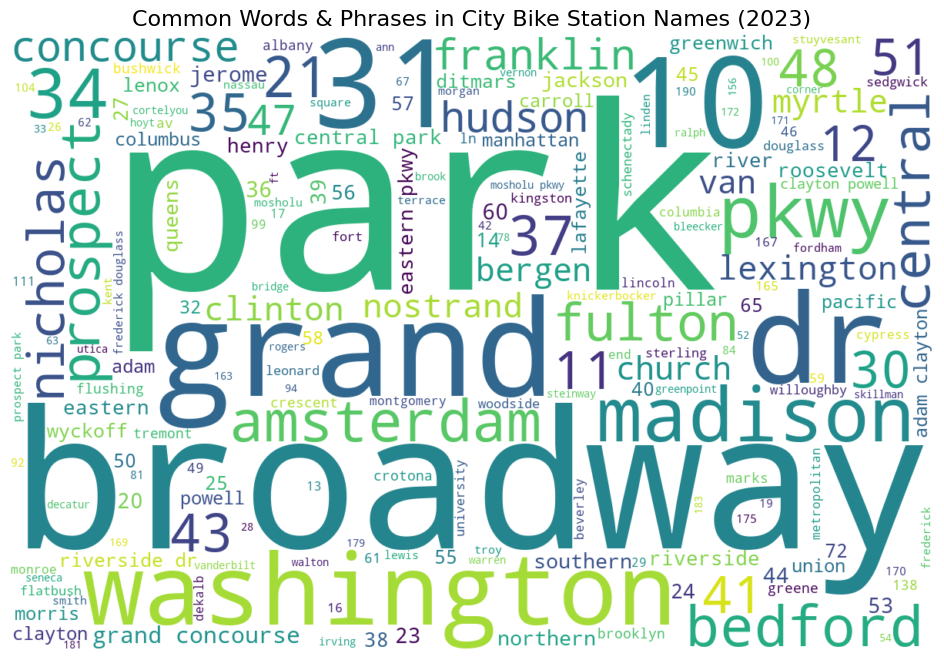

In [21]:
# using the top terms to keep the cloud readable
top_n = 200
freq_map = dict(
    zip(
        ngram_table.loc[: top_n - 1, "term"],
        ngram_table.loc[: top_n - 1, "count"],
    )
)

# the word cloud
wc = WordCloud(
    width=1200,
    height=800,
    background_color="white",
    max_words=200,
    collocations=False
).generate_from_frequencies(freq_map)
plt.figure(figsize=(12, 8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Common Words & Phrases in City Bike Station Names (2023)", fontsize=16)
plt.show()

The word cloud highlights the most common location-based terms found in station names, with big standouts like park, broadway, and washington appearing across many sites. Numbers such as 10, 31, or 34 also show up because they come directly from station names (e.g., 10th Ave, 31st St), reflecting how closely the bike network mirrors real NYC streets and landmarks.

### 3.4.3 A simple bar chart of top terms

In [22]:
top_k = 25
top_terms = ngram_table.head(top_k)
(
    alt.Chart(top_terms)
    .mark_bar()
    .encode(
        x=alt.X("count:Q", title="Number of words"),
        y=alt.Y("term:N", sort="-x", title="Word / Phrase"),
        tooltip=["term", "count"],
    )
    .properties(
        title="Top Station-Related Words & Phrases",
        width=600,
        height=400,
    )
)

alt.Chart(...)

The bar chart clearly shows which station words appear the most, with big ones like park and broadway standing out. The tooltip also makes it easy to see the exact number for each word when you hover over it.